<a href="https://colab.research.google.com/github/nietbaeviysa/Karakalpak-NLP/blob/main/notebooks/frequency_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pdfplumber -q

from google.colab import drive
drive.mount('/content/drive')
print("Drive подключён!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.4/62.4 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 31.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 33.2 MB/s eta 0:00:00
Mounted at /content/drive
Drive подключён!


In [4]:
import os

path = '/content/drive/MyDrive/Karakalpak-NLP'
files = os.listdir(path)
print("Файлы в папке:")
for f in files:
    print(f)

Файлы в папке:
.git
.gitignore
LICENSE
data
notebooks
src
docs
README.md


In [7]:
import os

# Ищем все PDF файлы в папке
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if file.endswith('.pdf'):
            print(os.path.join(root, file))

/content/drive/MyDrive/Справка_с_места.pdf
/content/drive/MyDrive/сертификат.pdf
/content/drive/MyDrive/Karakalpak-NLP/data/raw/traditional/kitapxana.com_qiriq_qiz.pdf
/content/drive/MyDrive/Karakalpak-NLP/data/raw/traditional/kitapxana.com_qoblan.pdf
/content/drive/MyDrive/Karakalpak-NLP/data/raw/traditional/kitapxana.com_er-ziywar-qurbanbek.pdf


In [9]:
import pdfplumber
from collections import Counter
import matplotlib.pyplot as plt

# Все три дастана
dastans = {
    'Қырқ қыз': '/content/drive/MyDrive/Karakalpak-NLP/data/raw/traditional/kitapxana.com_qiriq_qiz.pdf',
    'Қоблан': '/content/drive/MyDrive/Karakalpak-NLP/data/raw/traditional/kitapxana.com_qoblan.pdf',
    'Ер Зияр': '/content/drive/MyDrive/Karakalpak-NLP/data/raw/traditional/kitapxana.com_er-ziywar_qurbanbek.pdf'
}

# Читаем все тексты
texts = {}
for name, path in dastans.items():
    text = ""
    with pdfplumber.open(path) as pdf:
        for page in pdf.pages:
            text += page.extract_text() or ""
    texts[name] = text
    print(f"{name}: {len(text)} символов")

print("\nВсе файлы прочитаны!")
print("Пример текста из Қырқ қыз:")
print(texts['Қырқ қыз'][:300])

Қырқ қыз: 303154 символов
Қоблан: 297746 символов


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Karakalpak-NLP/data/raw/traditional/kitapxana.com_er-ziywar_qurbanbek.pdf'

In [11]:
import os

path = '/content/drive/MyDrive/Karakalpak-NLP/data/raw/traditional/'
files = os.listdir(path)
for f in files:
    print(repr(f))

'.gitkeep'
'kitapxana.com_qiriq_qiz.pdf'
'kitapxana.com_qoblan.pdf'
'kitapxana.com_er-ziywar-qurbanbek.pdf'
'kyrk_kyz.txt'


In [13]:
import pdfplumber
from collections import Counter
import matplotlib.pyplot as plt

base = '/content/drive/MyDrive/Karakalpak-NLP/data/raw/traditional/'

# Читаем два PDF и один TXT
texts = {}

# Қырқ қыз из TXT — самый чистый текст
with open(base + 'kyrk_kyz.txt', 'r', encoding='utf-8') as f:
    texts['Қырқ қыз'] = f.read()

# Қоблан из PDF
with pdfplumber.open(base + 'kitapxana.com_qoblan.pdf') as pdf:
    text = ""
    for page in pdf.pages:
        text += page.extract_text() or ""
    texts['Қоблан'] = text

# Ер Зияр из PDF
with pdfplumber.open(base + 'kitapxana.com_er-ziywar-qurbanbek.pdf') as pdf:
    text = ""
    for page in pdf.pages:
        text += page.extract_text() or ""
    texts['Ер Зияр'] = text

# Результат
for name, text in texts.items():
    print(f"{name}: {len(text)} символов")

print("\nПример из Қырқ қыз:")
print(texts['Қырқ қыз'][:300])

Қырқ қыз: 17141 символов
Қоблан: 297746 символов
Ер Зияр: 334783 символов

Пример из Қырқ қыз:
**Қырық қыз**

(Қабыл Мақсетов жазып алған, Қыяс жыраў атқарған)

*Халық*

**Мазмуны:**

Биринши бөлим — 3  
Екинши бөлим — 24  
Үшинши бөлим — 46  
Төртинши бөлим — 62  
Бесинши бөлим — 88  
Алтыншы бөлим — 134  
Жетинши бөлим — 175  
Сегизинши бөлим — 200  
Тоғызыншы бөлим — 245  
Оныншы бөлим — 2


In [15]:
# Частотный анализ всех трёх дастанов
import re

def analyze_text(text, name):
    # Очищаем текст — убираем символы форматирования
    text = re.sub(r'[*#\[\]()—–\d]', ' ', text)

    # Разбиваем на слова
    words = text.lower().split()

    # Убираем короткие слова (менее 3 букв)
    words = [w.strip('.,!?;:»«') for w in words if len(w) > 2]

    freq = Counter(words)
    return freq

# Анализируем каждый дастан
freqs = {}
for name, text in texts.items():
    freqs[name] = analyze_text(text, name)
    print(f"{name} — уникальных слов: {len(freqs[name])}")

# Объединённый корпус
all_words = Counter()
for freq in freqs.values():
    all_words += freq

print(f"\nВесь корпус — уникальных слов: {len(all_words)}")
print(f"\nТоп-20 слов во всём корпусе:")
for word, count in all_words.most_common(20):
    print(f"  {word}: {count}")

Қырқ қыз — уникальных слов: 1282
Қоблан — уникальных слов: 9318
Ер Зияр — уникальных слов: 11474

Весь корпус — уникальных слов: 17343

Топ-20 слов во всём корпусе:
  қарақалпақ: 1016
  деп: 978
  бир: 835
  қоблан: 804
  халық: 718
  kitapxana.com: 666
  әдебиятының: 666
  электрон: 666
  китапханасы: 666
  зийўар: 574
  менен: 537
  бул: 503
  қурбанбек: 430
  бар: 407
  еди: 356
  фольклоры: 350
  қырқ: 321
  болып: 306
  хан: 297
  алып: 297


Словарь сохранён — 17293 уникальных слов!


(Text(0.5, 1.0, 'Karakalpak tili soz lugu\nDastanlar korpusi: Qiriq qiz, Qoblan, Er Ziyar'),)

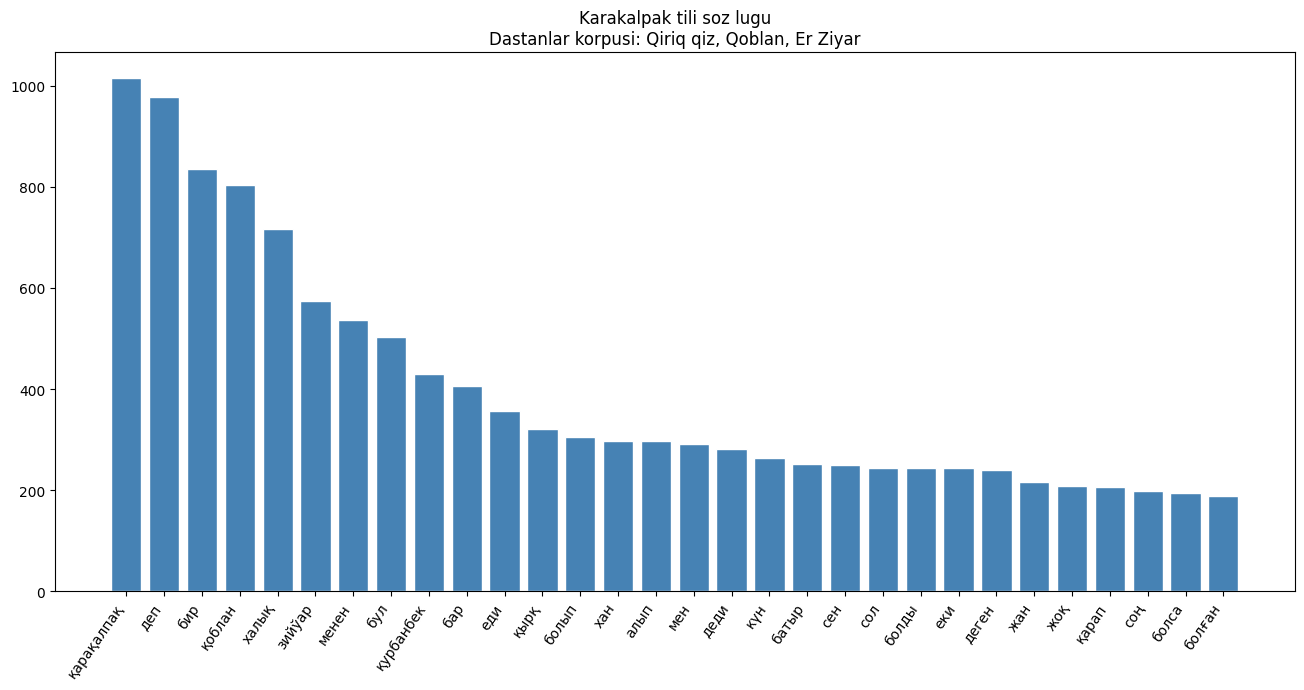

In [18]:
# Убираем ТОЛЬКО мусор от PDF — не трогаем язык
pdf_garbage = {
    'kitapxana.com', 'электрон', 'китапханасы',
    'әдебиятының', 'фольклоры', 'kitapxana'
}

full_vocab = Counter({
    word: count for word, count in all_words.items()
    if word not in pdf_garbage and len(word) > 2
})

# Сохраняем словарь в CSV
import csv

with open('/content/drive/MyDrive/Karakalpak-NLP/karakalpak_vocabulary.csv',
          'w', encoding='utf-8', newline='') as f:
    writer = csv.writer(f)
    writer.writerow(['word', 'frequency', 'source'])
    for word, count in full_vocab.most_common():
        writer.writerow([word, count, 'dastan_corpus'])

print(f"Словарь сохранён — {len(full_vocab)} уникальных слов!")

# График топ-30
top_30 = full_vocab.most_common(30)
labels, values = zip(*top_30)

plt.figure(figsize=(16, 7))
plt.bar(labels, values, color='steelblue', edgecolor='white')
plt.xticks(rotation=55, ha='right', fontsize=10)
plt.title('Karakalpak tili soz lugu\nDastanlar korpusi: Qiriq qiz, Qoblan, Er Ziyar'),